# Лабораторная работа 4: Деревья. Случайный лес

## Часть 1: Основы построения решающие дерева

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
counts = np.array([8, 2], dtype=float)
probs = counts / counts.sum()

entropy = -np.sum(probs * np.log(probs))
print("Энтропия H(R_m):", entropy)
print("Округлённый ответ:", round(entropy, 2))

Энтропия H(R_m): 0.5004024235381879
Округлённый ответ: 0.5


**Задание 1.2** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
gini = np.sum(probs * (1 - probs))
print("Критерий информативности (энтропия):", round(entropy, 2))
print("Индекс Джини H(R_m):", gini)
print("Критерий информативности (Джини):", gini)
print("Округлённый ответ (Джини):", round(gini, 2))

Критерий информативности (энтропия): 0.5
Индекс Джини H(R_m): 0.32
Критерий информативности (Джини): 0.32
Округлённый ответ (Джини): 0.32


**Задание 1.3** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
values = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47], dtype=float)
prediction = values.mean()

print("Среднее по листу:", prediction)

Среднее по листу: 40.6


## Часть 2: Решающие деревья

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [6]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    feature_vector = np.array(feature_vector)
    target_vector = np.array(target_vector)
     # Функция "хаотичности" H(R)
    def impurity(y):
        if y.size == 0:
            return 0.0
        if task == "regression":
            # дисперсия подвыборки
            return np.var(y)
        elif task == "classification":
            classes, counts = np.unique(y, return_counts=True)
            probs = counts / counts.sum()
            # индекс Джини: sum p_k(1-p_k)
            return np.sum(probs * (1 - probs))
        else:
            raise ValueError("Unknown task type")

    if feature_type == "real":
        # сортируем по признаку
        order = np.argsort(feature_vector)
        x = feature_vector[order]
        y = target_vector[order]

        unique_vals = np.unique(x)
        if unique_vals.size < 2:
            return np.array([]), np.array([]), None, None

        # пороги — середины между соседними значениями
        thresholds = (unique_vals[1:] + unique_vals[:-1]) / 2.0

    elif feature_type == "categorical":
        x = feature_vector
        y = target_vector
        # пороги — сами категории
        thresholds = np.unique(x)
    else:
        raise ValueError("Unknown feature_type")

    Hm = impurity(y)
    ginis = []
    gini_best = None
    threshold_best = None

    for thr in thresholds:
        if feature_type == "real":
            left_mask = x <= thr
        else:  # categorical
            left_mask = (x == thr)
        right_mask = ~left_mask

        # пропускаем пороги, которые делают пустой лист
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            ginis.append(np.nan)
            continue

        Hl = impurity(y[left_mask])
        Hr = impurity(y[right_mask])

        # прирост качества (информационный критерий)
        Q = Hm - (left_mask.mean()) * Hl - (right_mask.mean()) * Hr
        ginis.append(Q)

        if (gini_best is None) or (Q > gini_best):
            gini_best = Q
            threshold_best = thr

    ginis = np.array(ginis)
    return thresholds, ginis, threshold_best, gini_best

    pass

Эту функцию можно протестировать на датасете `California`.

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

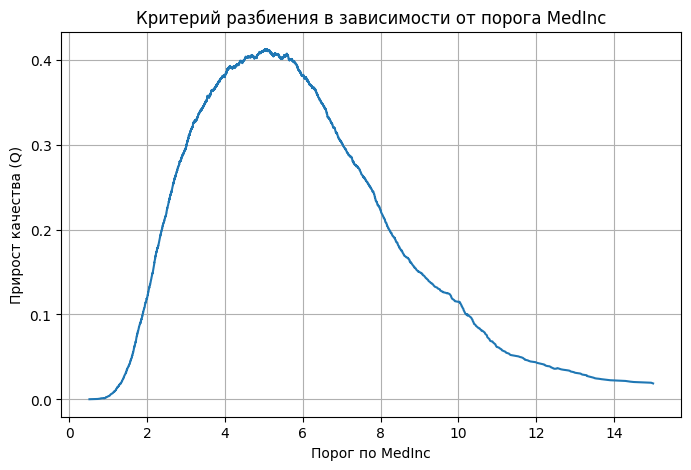

Лучший порог по MedInc: 5.03515
Максимальный прирост критерия: 0.4127513862016767


In [10]:
medinc = X["MedInc"].values

thresholds, ginis, threshold_best, gini_best = find_best_split(
    medinc,
    y,
    task="regression",
    feature_type="real"
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, ginis)
plt.xlabel("Порог по MedInc")
plt.ylabel("Прирост качества (Q)")
plt.title("Критерий разбиения в зависимости от порога MedInc")
plt.grid(True)
plt.show()

print("Лучший порог по MedInc:", threshold_best)
print("Максимальный прирост критерия:", gini_best)

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [11]:
print(f"Лучший предикат первой вершины: MedInc <= {threshold_best:.3f}")

Лучший предикат первой вершины: MedInc <= 5.035


**Задание 2.2** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [12]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    # объекты, у которых признак <= порога, идут в левое поддерево
                    split = feature_vector <= threshold_best
                elif feature_type == "categorical":
                    # в данной реализации threshold — конкретное значение категории
                    threshold_best = threshold
                    # объекты с этой категорией идут в левое поддерево
                    split = (feature_vector == threshold_best)
                else:
                    raise ValueError


        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
            return node["class"]

        # Иначе смотрим, по какому признаку разбиваем
        feature = node["feature_split"]
        feature_type = self._feature_types[feature]

        if feature_type == "real":
            threshold = node["threshold"]
            if x[feature] <= threshold:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif feature_type == "categorical":
            category = node["category_split"]
            if x[feature] == category:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        else:
            raise ValueError("Unknown feature type in node")
        pass

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

**Задание 2.3** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

Students file: students (2).csv


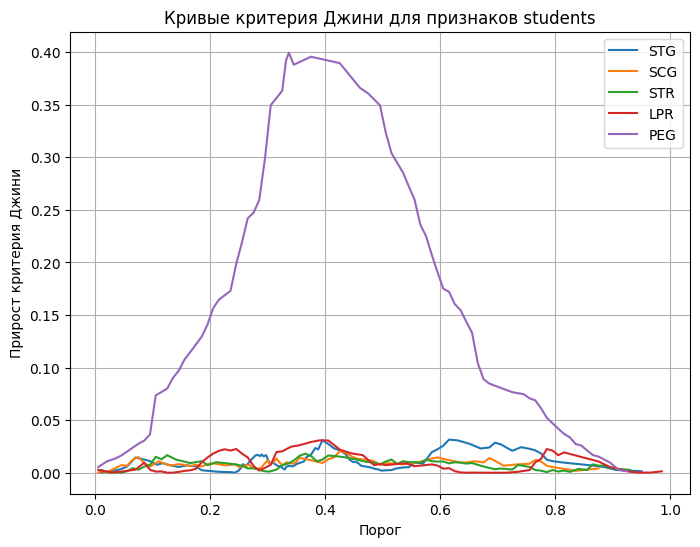

In [38]:
import glob

# Пытаемся найти файл с данными students рядом с ноутбуком (в Colab он обычно лежит в /content)
students_path_candidates = [
    'students.csv',
    'students*.csv'
]
students_path = None
for pat in students_path_candidates:
    matches = glob.glob(pat)
    if matches:
        students_path = matches[0]
        break
if students_path is None:
    raise FileNotFoundError('Не найден файл students*.csv. Проверьте, что файл загружен в текущую директорию.')

students = pd.read_csv(students_path)
print('Students file:', students_path)

# Уберём технический столбец, если он есть
if 'Unnamed: 0' in students.columns:
    students = students.drop(columns=['Unnamed: 0'])

feature_cols = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
X_st = students[feature_cols]
y_st = students['UNS']

plt.figure(figsize=(8, 6))

for col in feature_cols:
    thresholds, ginis, threshold_best, gini_best = find_best_split(
        X_st[col].values,
        y_st.values,
        task='classification',
        feature_type='real'
    )
    plt.plot(thresholds, ginis, label=col)

plt.xlabel('Порог')
plt.ylabel('Прирост критерия Джини')
plt.title('Кривые критерия Джини для признаков students')
plt.legend()
plt.grid(True)
plt.show()



Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

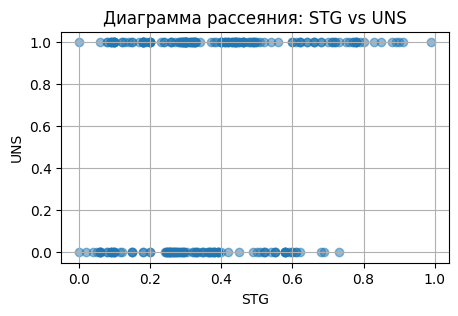

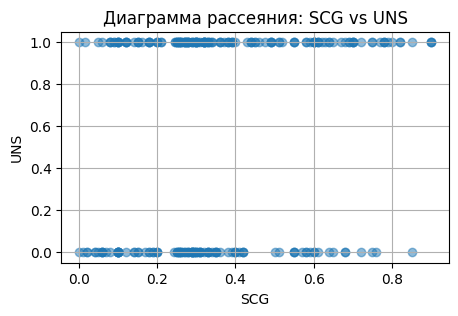

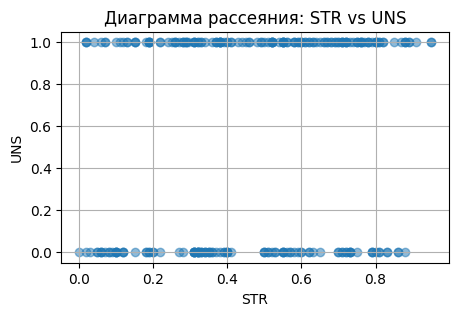

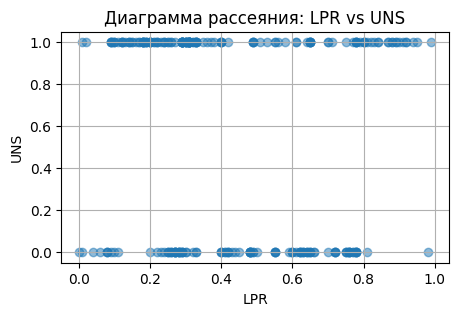

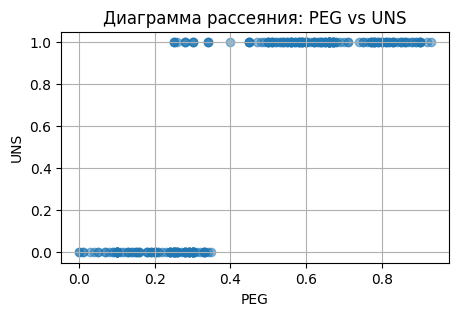

Лучший признак для разбиения корня по критерию Джини: PEG
Максимальный прирост критерия: 0.39939200196213387


In [39]:
# Диаграммы рассеяния "значение признака — класс"
for col in feature_cols:
    plt.figure(figsize=(5, 3))
    plt.scatter(X_st[col], y_st, alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("UNS")
    plt.title(f"Диаграмма рассеяния: {col} vs UNS")
    plt.grid(True)
    plt.show()

# Автоматически выберем лучший признак по максимальному приросту Джини
best_feature = None
best_score = None

for col in feature_cols:
    _, _, _, gini_best = find_best_split(
        X_st[col].values,
        y_st.values,
        task="classification",
        feature_type="real"
    )
    if best_score is None or (gini_best is not None and gini_best > best_score):
        best_score = gini_best
        best_feature = col

print("Лучший признак для разбиения корня по критерию Джини:", best_feature)
print("Максимальный прирост критерия:", best_score)




**Задание 2.4** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [37]:
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1) читаем mushrooms
mush_files = glob.glob("agaricus-lepiota*.data")
if not mush_files:
    raise FileNotFoundError("Файл agaricus-lepiota*.data не найден в текущей директории Colab (/content).")
mush_path = mush_files[0]
print("Mushrooms file:", mush_path)

df_m = pd.read_csv(mush_path, header=None)

# 2) y и X
y_m = df_m[0].map({"e": 0, "p": 1}).astype(int).values
X_m = df_m.drop(columns=[0]).copy()

# заменим '?' и закодируем категории числами
X_m = X_m.replace("?", np.nan)
for c in X_m.columns:
    X_m[c] = X_m[c].astype("category").cat.codes  # NaN -> -1

X_m = X_m.values
feature_types_m = ["categorical"] * X_m.shape[1]

# 3) split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.30, random_state=42, stratify=y_m
)

# 4) модель (можно оставить max_depth=None)
tree_mush = DecisionTree(
    feature_types=feature_types_m,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    task="classification"
)

tree_mush.fit(X_train_m, y_train_m)
y_pred_m = tree_mush.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test_m, y_pred_m))



Mushrooms file: agaricus-lepiota (2).data
Accuracy: 1.0


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [18]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [19]:
import glob
diabetes_path_candidates = [
    'diabetes.csv',
    'diabetes*.csv'
]
diabetes_path = None
for pat in diabetes_path_candidates:
    matches = glob.glob(pat)
    if matches:
        diabetes_path = matches[0]
        break
if diabetes_path is None:
    raise FileNotFoundError('Не найден файл diabetes*.csv. Проверьте, что файл загружен в текущую директорию.')

data = pd.read_csv(diabetes_path)
print('Diabetes file:', diabetes_path)
print(f'Dataset shape: {data.shape}')
data.head()

Diabetes file: diabetes (1) (2).csv
Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

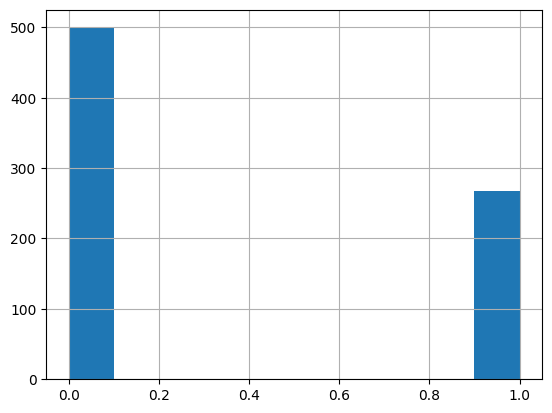

In [20]:
data['Outcome'].hist()
plt.show()

**Задание 3.1** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [21]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.3,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Train_full shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Train shape: (375, 8)
Val shape: (162, 8)
Train_full shape: (537, 8)
Test shape: (231, 8)


**Задание 3.2** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [22]:
from sklearn.metrics import f1_score

max_depth_values = [3, 4, 5, 6, None]
min_samples_leaf_values = [1, 2, 4, 8]

best_f1 = None
best_params = {}

for max_depth in max_depth_values:
    for min_leaf in min_samples_leaf_values:
        clf = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            random_state=42
        )
        clf.fit(X_train, y_train)
        y_val_pred = clf.predict(X_val)
        f1 = f1_score(y_val, y_val_pred)
        print(f"max_depth={max_depth}, min_samples_leaf={min_leaf}, F1={f1:.3f}")

        if (best_f1 is None) or (f1 > best_f1):
            best_f1 = f1
            best_params = {"max_depth": max_depth, "min_samples_leaf": min_leaf}

print("\nЛучшие параметры для дерева:", best_params, "F1:", best_f1)

# Обучаем дерево с лучшими гиперпараметрами на ПОЛНОЙ обучающей выборке
best_tree = DecisionTreeClassifier(
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42
)
best_tree.fit(X_train_full, y_train_full)

y_test_pred = best_tree.predict(X_test)
y_test_proba = best_tree.predict_proba(X_test)[:, 1]

print("\nDecisionTree (best params) — качество на тесте:")
print("accuracy:", accuracy_score(y_test, y_test_pred))
print("precision:", precision_score(y_test, y_test_pred))
print("recall:", recall_score(y_test, y_test_pred))
print("roc_auc:", roc_auc_score(y_test, y_test_proba))

max_depth=3, min_samples_leaf=1, F1=0.500
max_depth=3, min_samples_leaf=2, F1=0.500
max_depth=3, min_samples_leaf=4, F1=0.500
max_depth=3, min_samples_leaf=8, F1=0.532
max_depth=4, min_samples_leaf=1, F1=0.505
max_depth=4, min_samples_leaf=2, F1=0.500
max_depth=4, min_samples_leaf=4, F1=0.485
max_depth=4, min_samples_leaf=8, F1=0.454
max_depth=5, min_samples_leaf=1, F1=0.545
max_depth=5, min_samples_leaf=2, F1=0.532
max_depth=5, min_samples_leaf=4, F1=0.523
max_depth=5, min_samples_leaf=8, F1=0.544
max_depth=6, min_samples_leaf=1, F1=0.517
max_depth=6, min_samples_leaf=2, F1=0.486
max_depth=6, min_samples_leaf=4, F1=0.404
max_depth=6, min_samples_leaf=8, F1=0.449
max_depth=None, min_samples_leaf=1, F1=0.436
max_depth=None, min_samples_leaf=2, F1=0.453
max_depth=None, min_samples_leaf=4, F1=0.491
max_depth=None, min_samples_leaf=8, F1=0.459

Лучшие параметры для дерева: {'max_depth': 5, 'min_samples_leaf': 1} F1: 0.5454545454545454

DecisionTree (best params) — качество на тесте:
accura

**Задание 3.3** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [23]:
# BaggingClassifier: в новых версиях sklearn параметр называется estimator, в старых — base_estimator
base_tree = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

try:
    bagging = BaggingClassifier(
        estimator=base_tree,
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
except TypeError:
    bagging = BaggingClassifier(
        base_estimator=base_tree,
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )

bagging.fit(X_train_full, y_train_full)
y_test_pred_bag = bagging.predict(X_test)
y_test_proba_bag = bagging.predict_proba(X_test)[:, 1]

print('Bagging (50 деревьев) — качество на тесте:')
print('accuracy:', accuracy_score(y_test, y_test_pred_bag))
print('precision:', precision_score(y_test, y_test_pred_bag))
print('recall:', recall_score(y_test, y_test_pred_bag))
print('roc_auc:', roc_auc_score(y_test, y_test_proba_bag))



Bagging (50 деревьев) — качество на тесте:
accuracy: 0.7619047619047619
precision: 0.696969696969697
recall: 0.5679012345679012
roc_auc: 0.8362139917695474


**Задание 3.4** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [24]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

max_depth_grid = [2, 3, 4, 5, 6, 8, 10, None]
min_samples_split_grid = [2, 5, 10, 20]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_mean_f1 = -1.0
best_rf_params = None
cv_results = []

for md in max_depth_grid:
    for mss in min_samples_split_grid:
        fold_scores = []
        for train_idx, val_idx in cv.split(X_train_full, y_train_full):
            X_tr = X_train_full.iloc[train_idx]
            X_va = X_train_full.iloc[val_idx]
            y_tr = y_train_full.iloc[train_idx]
            y_va = y_train_full.iloc[val_idx]

            rf = RandomForestClassifier(
                n_estimators=50,
                max_depth=md,
                min_samples_split=mss,
                random_state=42,
                n_jobs=-1
            )
            rf.fit(X_tr, y_tr)
            y_va_pred = rf.predict(X_va)
            fold_scores.append(f1_score(y_va, y_va_pred))

        mean_f1 = float(np.mean(fold_scores))
        cv_results.append((md, mss, mean_f1))
        print(f"max_depth={md}, min_samples_split={mss}, mean_f1={mean_f1:.4f}")

        if mean_f1 > best_mean_f1:
            best_mean_f1 = mean_f1
            best_rf_params = {"max_depth": md, "min_samples_split": mss}

print("\nЛучшие параметры RandomForest:", best_rf_params, "mean_f1:", best_mean_f1)

best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_rf_params["max_depth"],
    min_samples_split=best_rf_params["min_samples_split"],
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_full, y_train_full)
y_test_pred_rf = best_rf.predict(X_test)
y_test_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nRandomForest (50 деревьев, best params) — качество на тесте:")
print("accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("precision:", precision_score(y_test, y_test_pred_rf))
print("recall:", recall_score(y_test, y_test_pred_rf))
print("roc_auc:", roc_auc_score(y_test, y_test_proba_rf))

# Сравнение трёх моделей на тесте по F1 и ROC AUC
models_summary = {
    "DecisionTree": {
        "f1": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba)
    },
    "Bagging(50)": {
        "f1": f1_score(y_test, y_test_pred_bag),
        "roc_auc": roc_auc_score(y_test, y_test_proba_bag)
    },
    "RandomForest(50)": {
        "f1": f1_score(y_test, y_test_pred_rf),
        "roc_auc": roc_auc_score(y_test, y_test_proba_rf)
    }
}

print("\nСводка (test):")
for name, m in models_summary.items():
    print(f"{name:16s} | F1={m['f1']:.4f} | ROC_AUC={m['roc_auc']:.4f}")


max_depth=2, min_samples_split=2, mean_f1=0.5337
max_depth=2, min_samples_split=5, mean_f1=0.5337
max_depth=2, min_samples_split=10, mean_f1=0.5337
max_depth=2, min_samples_split=20, mean_f1=0.5337
max_depth=3, min_samples_split=2, mean_f1=0.5821
max_depth=3, min_samples_split=5, mean_f1=0.5801
max_depth=3, min_samples_split=10, mean_f1=0.5855
max_depth=3, min_samples_split=20, mean_f1=0.6058
max_depth=4, min_samples_split=2, mean_f1=0.5851
max_depth=4, min_samples_split=5, mean_f1=0.5723
max_depth=4, min_samples_split=10, mean_f1=0.5827
max_depth=4, min_samples_split=20, mean_f1=0.5889
max_depth=5, min_samples_split=2, mean_f1=0.6191
max_depth=5, min_samples_split=5, mean_f1=0.6095
max_depth=5, min_samples_split=10, mean_f1=0.6277
max_depth=5, min_samples_split=20, mean_f1=0.6198
max_depth=6, min_samples_split=2, mean_f1=0.6103
max_depth=6, min_samples_split=5, mean_f1=0.6180
max_depth=6, min_samples_split=10, mean_f1=0.6226
max_depth=6, min_samples_split=20, mean_f1=0.6203
max_depth=

**Задание 3.5** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

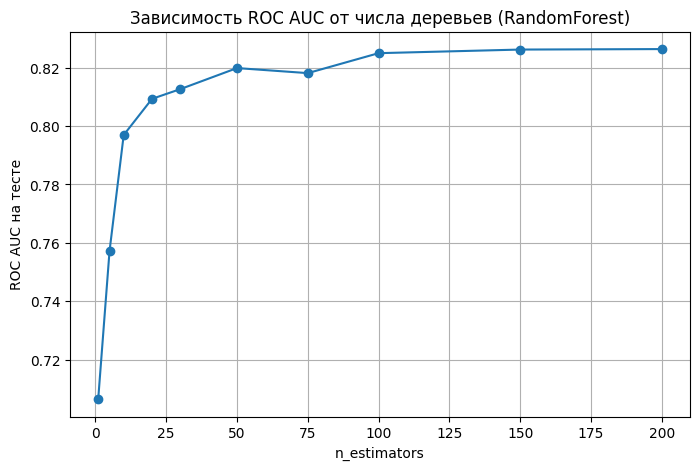

n_estimators=  1 -> ROC AUC=0.7065
n_estimators=  5 -> ROC AUC=0.7572
n_estimators= 10 -> ROC AUC=0.7969
n_estimators= 20 -> ROC AUC=0.8093
n_estimators= 30 -> ROC AUC=0.8126
n_estimators= 50 -> ROC AUC=0.8198
n_estimators= 75 -> ROC AUC=0.8181
n_estimators=100 -> ROC AUC=0.8249
n_estimators=150 -> ROC AUC=0.8262
n_estimators=200 -> ROC AUC=0.8263


In [25]:
# График зависимости AUC ROC от числа деревьев
n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
auc_list = []

for n_estimators in n_estimators_list:
    rf_tmp = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=best_rf_params['max_depth'],
        min_samples_split=best_rf_params['min_samples_split'],
        random_state=42,
        n_jobs=-1
    )
    rf_tmp.fit(X_train_full, y_train_full)
    proba = rf_tmp.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    auc_list.append(auc)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, auc_list, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('ROC AUC на тесте')
plt.title('Зависимость ROC AUC от числа деревьев (RandomForest)')
plt.grid(True)
plt.show()

for n, auc in zip(n_estimators_list, auc_list):
    print(f'n_estimators={n:3d} -> ROC AUC={auc:.4f}')


**Задание 3.6** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

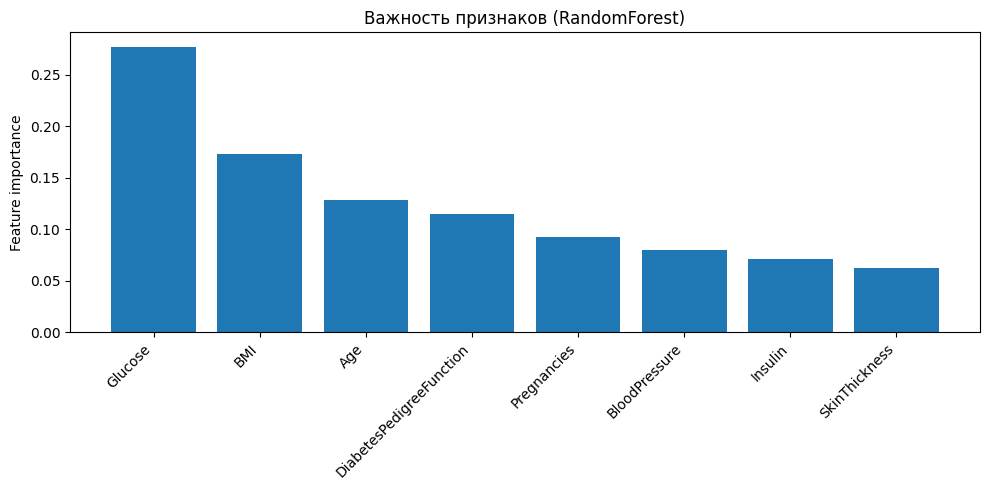

Самый важный признак: Glucose


In [26]:
importances = best_rf.feature_importances_
feature_names = X.columns

# сортируем по убыванию важности
idx_sorted = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(feature_names[idx_sorted], importances[idx_sorted])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Feature importance')
plt.title('Важность признаков (RandomForest)')
plt.tight_layout()
plt.show()

most_important_feature = feature_names[idx_sorted[0]]
print('Самый важный признак:', most_important_feature)